In [ ]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
from IPython import display

Загрузим аудио

In [ ]:
wav, sr = librosa.load("shoot.wav", sr=None, mono=True)
display.display(display.Audio(wav, rate=sr))

In [ ]:
target_sec = [13]

Отрисуем все амплитуды

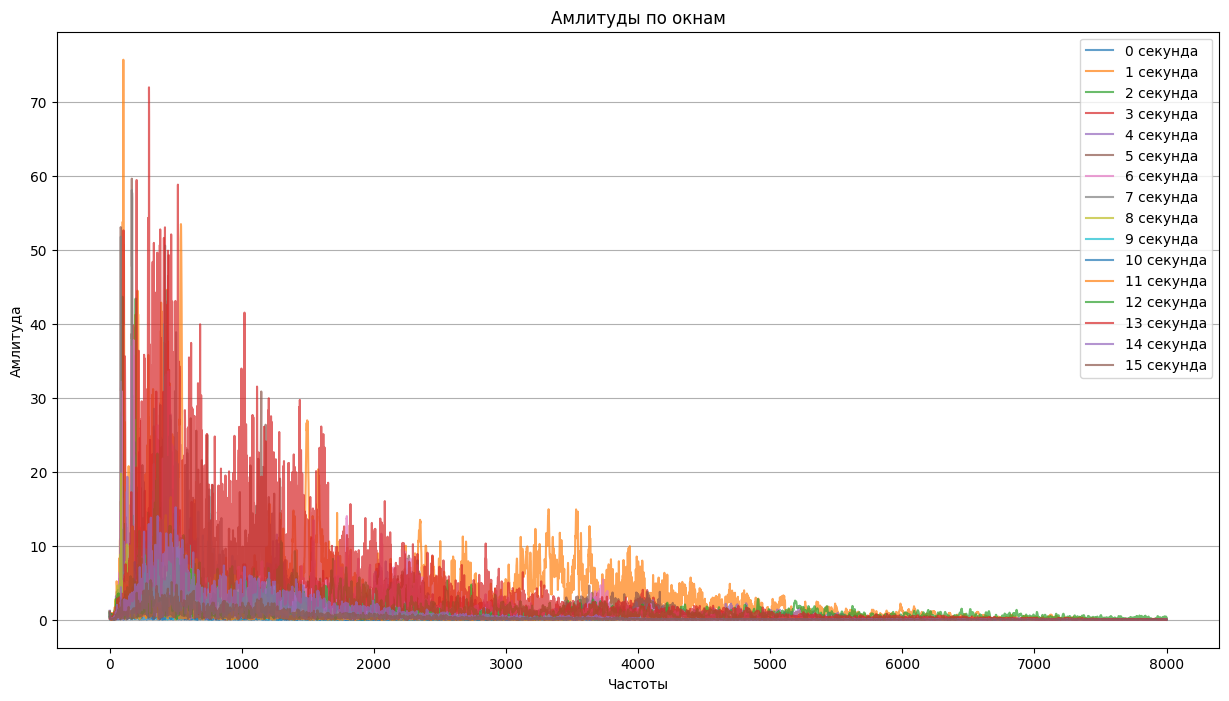

In [ ]:
amplitude_spec = np.abs(librosa.stft(wav, n_fft=sr, hop_length=sr))
plt.figure(figsize=(15, 8))
for i, spec in enumerate(amplitude_spec.T):
    plt.plot(spec, label=f"{i} секунда", alpha=0.7)
plt.xlabel("Частоты")
plt.ylabel("Амлитуда")
plt.title("Амлитуды по окнам")
plt.grid(True, "major", "y")
plt.legend()
plt.show()

Отрисуем амплитуды для аудио, которые далеко от выстрела

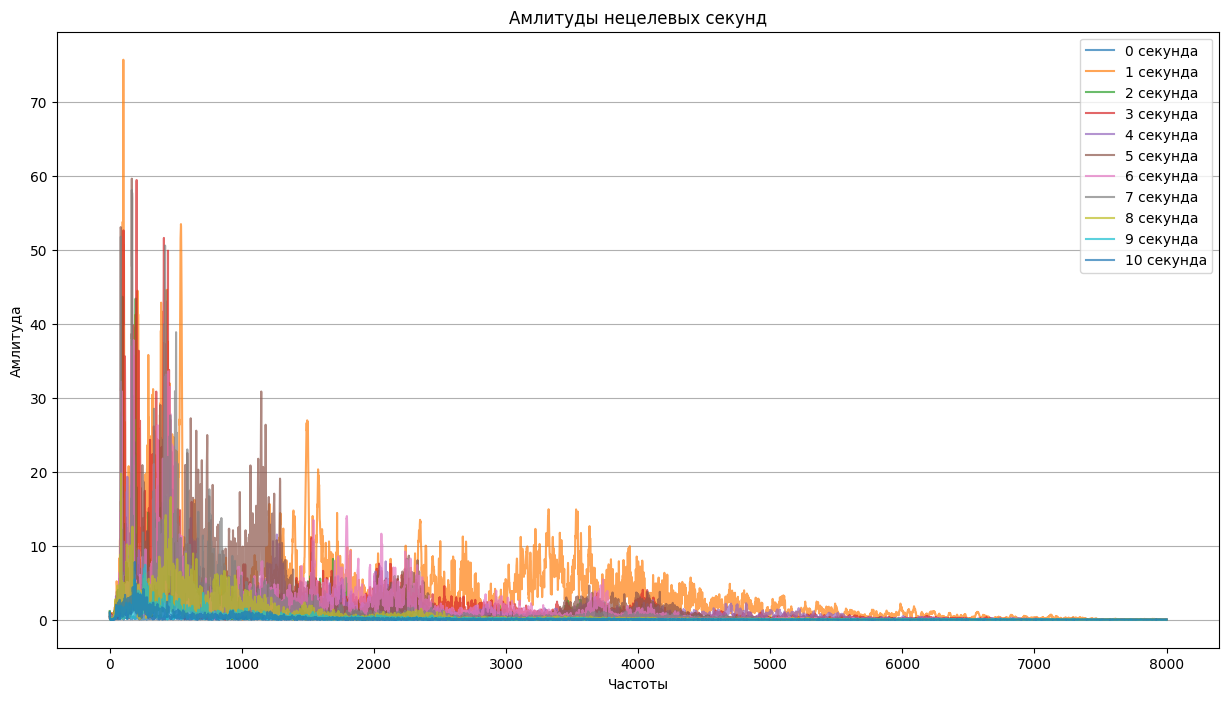

In [ ]:
plt.figure(figsize=(15, 8))
for i in range(11):
    plt.plot(amplitude_spec.T[i], label=f"{i} секунда", alpha=0.7)
plt.xlabel("Частоты")
plt.ylabel("Амлитуда")
plt.title("Амлитуды нецелевых секунд")
plt.grid(True, "major", "y")
plt.legend()
plt.show()

И которые близки к нему

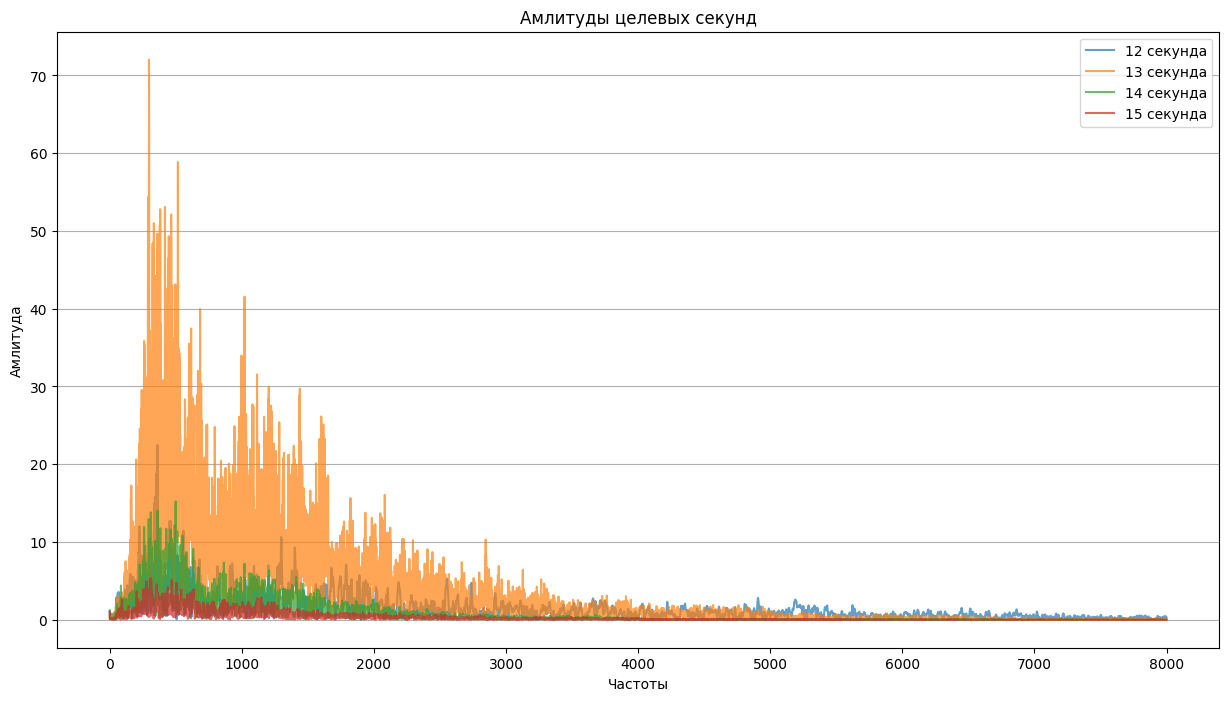

In [ ]:
plt.figure(figsize=(15, 8))
for i in range(12, len(amplitude_spec.T)):
    plt.plot(amplitude_spec.T[i], label=f"{i} секунда", alpha=0.7)
plt.xlabel("Частоты")
plt.ylabel("Амлитуда")
plt.title("Амлитуды целевых секунд")
plt.grid(True, "major", "y")
plt.legend()
plt.show()

Обрезаем ненужные частоты, падим, чтобы отрисовка показывала правильные частоты по `х`

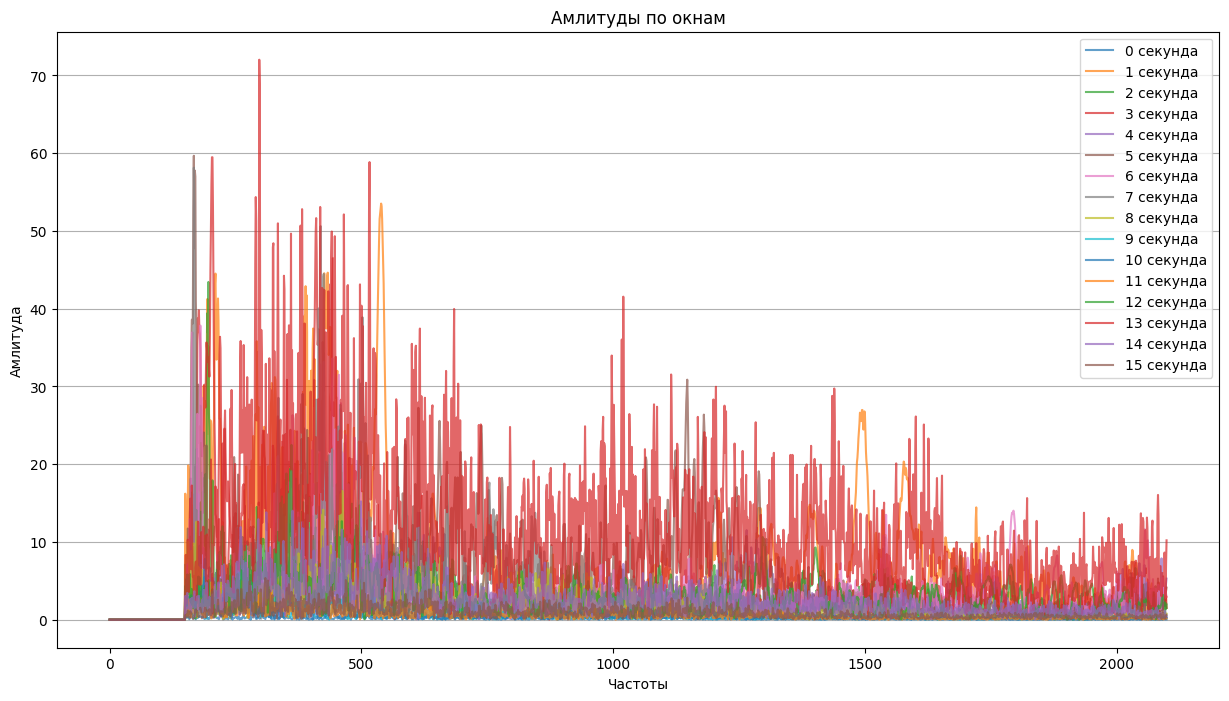

In [ ]:
low_cut = 150
high_cut = 2100
cut_amplitude_spec = amplitude_spec[low_cut:high_cut, :]
plt.figure(figsize=(15, 8))
for i in range(len(cut_amplitude_spec.T)):
    plt.plot(np.pad(cut_amplitude_spec.T[i], (low_cut, 0)), label=f"{i} секунда", alpha=0.7)
plt.xlabel("Частоты")
plt.ylabel("Амлитуда")
plt.title("Амлитуды по окнам")
plt.grid(True, "major", "y")
plt.legend()
plt.show()

Классифицируем через громкость частоты выстрела

In [ ]:
np.any(cut_amplitude_spec > 60, axis=0)

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False])

То же самое, но с энергией

In [ ]:
energy = np.sum(amplitude_spec**2, axis=0)
energy, energy > 3.8e5

(array([1.0234135e+02, 3.7527091e+05, 4.6250719e+04, 1.9749384e+05,
        3.6349289e+04, 1.6673270e+05, 9.2866555e+04, 8.0995852e+04,
        2.0695887e+04, 2.2189983e+03, 1.6923965e+03, 2.1050493e+03,
        4.2644113e+04, 4.6046172e+05, 2.1307555e+04, 3.1286355e+03],
       dtype=float32),
 array([False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True, False, False]))

# Вывод

В ходе проделанной работы мы научились двумя способами классифицировать выстрел в аудио с посторонними шумами